In [ ]:
import pandapower as pp
import pandapower.networks as nw
import math
import pandapower.plotting as plot
import matplotlib.pyplot as plt
import pandapower.plotting.plotly as pplotly
import pandapower.plotting as plot
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.colors as pcolors
import csv
import tqdm
from pathlib import Path
import json

In [ ]:
def plot_net(net):
    def _parse_point(geo_value):
        if pd.isna(geo_value):
            return None
        geo_obj = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
        x, y = geo_obj["coordinates"]
        return pd.Series({"x": float(x), "y": float(y)})

    def _get_bus_coords(net):
        if hasattr(net, "bus_geodata") and not net.bus_geodata.empty and {"x", "y"}.issubset(net.bus_geodata.columns):
            return net.bus_geodata[["x", "y"]].astype(float)

        if "geo" not in net.bus.columns or net.bus.geo.dropna().empty:
            plot.create_generic_coordinates(net, overwrite=True)

        bus_coords = net.bus.geo.dropna().apply(_parse_point)
        if bus_coords.empty:
            raise ValueError("No bus coordinates are available for plotting.")
        return bus_coords
    
    components = []

    pp.rundcopp(net)
    bus_coords = _get_bus_coords(net)

    vn_kv = net.bus.loc[net.line.from_bus.values, 'vn_kv'].values
    max_i_ka = net.line.max_i_ka.values
    max_load_mw = np.sqrt(3) * vn_kv * max_i_ka

    line_hover = pd.Series(
        ("Line " + net.line.index.astype(str) + \
        "<br>From: Bus " + net.line.from_bus.astype(str) + \
        "  To: Bus " + net.line.to_bus.astype(str) + \
        "<br>P_flow: " + abs(net.res_line.p_from_mw).round(2).astype(str) + " MW" + \
        "<br>Max Cap: " + np.round(max_load_mw, 2).astype(str) + " MW" + \
        "<br>Loading: " + net.res_line.loading_percent.round(2).astype(str) + " %").values,
        index=net.line.index
    )

    gen_cost = net.gen.index.map(
        net.poly_cost.loc[net.poly_cost.et == 'gen'].set_index('element')['cp1_eur_per_mw']
    ).fillna(0).round(2).astype(str)
    gen_hover = pd.Series(
        ("Gen " + net.gen.index.astype(str) +
        "<br>P_out: " + net.res_gen.p_mw.round(2).astype(str) + " MW" +
        "<br>Min P: " + net.gen.min_p_mw.round(2).astype(str) + " MW" +
        "<br>Max P: " + net.gen.max_p_mw.round(2).astype(str) + " MW" +
        "<br>Cost: " + gen_cost.values + " $/MW").values,
        index=net.gen.bus.values
    )

    ext_cost = net.ext_grid.index.map(
        net.poly_cost.loc[net.poly_cost.et == 'ext_grid'].set_index('element')['cp1_eur_per_mw']
    ).fillna(0).round(2).astype(str)
    ext_hover = pd.Series(
        ("Ext Grid " + net.ext_grid.index.astype(str) +
        "<br>P_out: " + net.res_ext_grid.p_mw.round(2).astype(str) + " MW" +
        "<br>Min P: " + net.ext_grid.min_p_mw.round(2).astype(str) + " MW" +
        "<br>Max P: " + net.ext_grid.max_p_mw.round(2).astype(str) + " MW" +
        "<br>Cost: " + ext_cost.values + " $/MW").values,
        index=net.ext_grid.bus.values
    )

    lmp_col = next((col for col in ["lam_p", "marginal_price"] if col in net.res_bus.columns), None)
    
    
    _values = (
        net.load.bus.map(net.res_bus[lmp_col]).round(2).astype(str) + " $/MWh"
        if lmp_col is not None else pd.Series(["N/A"] * len(net.load), index=net.load.index)
    )
    load_hover = pd.Series(
        ("Load " + net.load.index.astype(str) +
        "<br>Bus: " + net.load.bus.astype(str) +
        "<br>P_in: " + net.res_load.p_mw.round(2).astype(str) + " MW" +
        "<br>LMP: " + lmp_values.values).values,
        index=net.load.bus.values
    )

    line_trace = pplotly.create_line_trace(
        net, use_line_geo=False, cmap="jet", cmap_vals=net.res_line.loading_percent,
        cmin=0, cmax=100, infofunc=line_hover, width=3.0
    )
    for trace in line_trace:
        if 'marker' in trace and 'showscale' in trace['marker']:
            trace['marker']['showscale'] = False
            trace['showlegend'] = False

    pure_buses = list(set(net.bus.index) - set(net.gen.bus) - set(net.load.bus) - set(net.ext_grid.bus))
    bus_trace = pplotly.create_bus_trace(
        net, buses=pure_buses, size=10, color="lightgray", trace_name="Buses",
        infofunc=pd.Series(("Bus " + net.bus.index.astype(str)).values, index=net.bus.index)
    )

    gen_trace = pplotly.create_bus_trace(
        net, buses=net.gen.bus.values, size=16, color="orange", trace_name="Generators", infofunc=gen_hover
    )

    load_trace = pplotly.create_bus_trace(
        net, buses=net.load.bus.values, size=16, color="blue", trace_name="Loads", infofunc=load_hover
    )

    ext_trace = pplotly.create_bus_trace(
        net, buses=net.ext_grid.bus.values, size=18, color="red", trace_name="Ext Grid (Slack)", infofunc=ext_hover
    )

    arrow_mid_x = []
    arrow_mid_y = []
    arrow_angles = []
    arrow_colors = []

    for idx, row in net.line.iterrows():
        if not row.in_service:
            continue

        from_bus = row.from_bus
        to_bus = row.to_bus
        if from_bus not in bus_coords.index or to_bus not in bus_coords.index:
            continue

        x0, y0 = bus_coords.loc[from_bus, ['x', 'y']]
        x1, y1 = bus_coords.loc[to_bus, ['x', 'y']]

        p_from = net.res_line.loc[idx, 'p_from_mw']
        loading = net.res_line.loc[idx, 'loading_percent']

        if pd.isna(p_from) or pd.isna(loading) or loading < 0.01:
            continue

        if p_from > 0:
            tail_x, tail_y = x0, y0
            head_x, head_y = x1, y1
        elif p_from < 0:
            tail_x, tail_y = x1, y1
            head_x, head_y = x0, y0
        else:
            continue

        mid_x = (x0 + x1) / 2
        mid_y = (y0 + y1) / 2
        arrow_mid_x.append(mid_x)
        arrow_mid_y.append(mid_y)

        angle_rad = np.arctan2(head_y - tail_y, head_x - tail_x)
        plotly_angle = 90 - np.degrees(angle_rad)
        arrow_angles.append(plotly_angle)

        norm_loading = np.clip(loading / 100.0, 0.0, 1.0)
        plotly_color = pcolors.sample_colorscale('jet', [norm_loading])[0]
        arrow_colors.append(plotly_color)

    arrow_trace = go.Scatter(
        x=arrow_mid_x,
        y=arrow_mid_y,
        mode='markers',
        marker=dict(
            symbol='triangle-up',
            size=14,
            color=arrow_colors,
            angle=arrow_angles,
            line=dict(color='black', width=0.5)
        ),
        showlegend=False,
        hoverinfo='skip',
    )

    traces = line_trace + bus_trace + gen_trace + load_trace + ext_trace + [arrow_trace]
    fig = go.Figure(data=traces)

    x_min, x_max = bus_coords['x'].min(), bus_coords['x'].max()
    y_min, y_max = bus_coords['y'].min(), bus_coords['y'].max()
    margin_x = (x_max - x_min) * 0.1 if x_max != x_min else 1
    margin_y = (y_max - y_min) * 0.1 if y_max != y_min else 1

    fig.update_layout(
        xaxis=dict(range=[x_min - margin_x, x_max + margin_x], title="X Coordinate"),
        yaxis=dict(scaleanchor="x", scaleratio=1, range=[y_min - margin_y, y_max + margin_y], title="Y Coordinate"),
        width=700, height=700,
        showlegend=True,
        template="plotly_white",
        hovermode="closest"
    )

    fig.show()


In [122]:
def load_caiso_timelines(time_data_dir="./time_data"):
    time_data_dir = Path(time_data_dir)
    demand_file = time_data_dir / "20260406_20260407_SLD_FCST_DAM_20260408_13_08_29_v1.csv"
    renewable_file = time_data_dir / "20260406_20260407_SLD_REN_FCST_DAM_20260408_13_08_02_v1.csv"

    def build_hourly_list(csv_path, filters):
        hourly_values = [None] * 24

        with csv_path.open(newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                if any(row[key] != value for key, value in filters.items()):
                    continue

                hour_index = int(row["OPR_HR"]) - 1
                hourly_values[hour_index] = float(row["MW"])

        missing_hours = [hour for hour, value in enumerate(hourly_values) if value is None]
        if missing_hours:
            raise ValueError(f"Missing data for hours: {missing_hours} with filters {filters}")

        return hourly_values

    def scale_to_unit_interval(values):
        max_value = max(values)
        if max_value == 0:
            return [0.0 for _ in values]
        return [value / max_value for value in values]

    demand_timeline = build_hourly_list(
        demand_file,
        {"TAC_AREA_NAME": "PGE-TAC"},
    )
    solar_timeline = build_hourly_list(
        renewable_file,
        {"TRADING_HUB": "NP15", "RENEWABLE_TYPE": "Solar"},
    )
    wind_timeline = build_hourly_list(
        renewable_file,
        {"TRADING_HUB": "NP15", "RENEWABLE_TYPE": "Wind"},
    )

    demand_timeline = scale_to_unit_interval(demand_timeline)
    solar_timeline = scale_to_unit_interval(solar_timeline)
    wind_timeline = scale_to_unit_interval(wind_timeline)

    return demand_timeline, solar_timeline, wind_timeline

In [ ]:
def simulate_workload_shift(dc_loads, wind_max=300, solar_max=300, demand_max=100, wind_ratio=1.0, solar_ratio=1.0, demand_ratio=1.0):
    net = nw.case9()

    net.gen.loc[0, 'min_p_mw'] = 0
    net.gen.loc[0, 'max_p_mw'] = wind_max * wind_ratio

    net.gen.loc[1, 'min_p_mw'] = 0
    net.gen.loc[1, 'max_p_mw'] = solar_max * solar_ratio

    net.ext_grid['min_p_mw'] = 0
    net.ext_grid['max_p_mw'] = 1000
    net.ext_grid['max_q_mvar'] = 1000
    net.ext_grid['min_q_mvar'] = -1000

    net.poly_cost.loc[(net.poly_cost['element'] == 0) & (net.poly_cost['et'] == 'ext_grid'), ['cp1_eur_per_mw']] = 10
    net.poly_cost.loc[(net.poly_cost['element'] == 0) & (net.poly_cost['et'] == 'ext_grid'), ['cp0_eur', 'cp2_eur_per_mw2']] = 0
    net.poly_cost.loc[(net.poly_cost['element'] == 0) & (net.poly_cost['et'] == 'gen'), ['cp0_eur', 'cp1_eur_per_mw', 'cp2_eur_per_mw2']] = 0
    net.poly_cost.loc[(net.poly_cost['element'] == 1) & (net.poly_cost['et'] == 'gen'), ['cp0_eur', 'cp1_eur_per_mw', 'cp2_eur_per_mw2']] = 0



    # max_i_ka = line_capacity_mw / (math.sqrt(3) * voltage_kv)
    for i in range(len(net.line)):
        net.line.loc[i, 'max_i_ka'] = 1000 / math.sqrt(3) / net.bus.loc[net.line.loc[i, 'from_bus'], 'vn_kv']
        
    net.line.loc[3, 'max_i_ka'] = solar_max / math.sqrt(3) / net.bus.loc[net.line.loc[3, 'from_bus'], 'vn_kv']
    net.line.loc[6, 'max_i_ka'] = wind_max / math.sqrt(3) / net.bus.loc[net.line.loc[6, 'from_bus'], 'vn_kv']
    
    net.line.loc[4, 'max_i_ka'] = solar_max / math.sqrt(3) / net.bus.loc[net.line.loc[4, 'from_bus'], 'vn_kv']
    net.line.loc[5, 'max_i_ka'] = wind_max / math.sqrt(3) / net.bus.loc[net.line.loc[5, 'from_bus'], 'vn_kv']
        
    net.line.loc[0, 'max_i_ka'] = 1000 / math.sqrt(3) / net.bus.loc[net.line.loc[0, 'from_bus'], 'vn_kv']
    net.line.loc[1, 'max_i_ka'] = 1000 / math.sqrt(3) / net.bus.loc[net.line.loc[1, 'from_bus'], 'vn_kv']
    net.line.loc[8, 'max_i_ka'] = 1000 / math.sqrt(3) / net.bus.loc[net.line.loc[8, 'from_bus'], 'vn_kv']
    net.line.loc[2, 'max_i_ka'] = 100 / math.sqrt(3) / net.bus.loc[net.line.loc[2, 'from_bus'], 'vn_kv']
    net.line.loc[7, 'max_i_ka'] = 100 / math.sqrt(3) / net.bus.loc[net.line.loc[7, 'from_bus'], 'vn_kv']
    
    
        
    net.line['x_ohm_per_km'] = 0.1
    
    for i in range(len(net.load)):
        net.load.loc[i, 'p_mw'] = demand_max * demand_ratio
        net.load.loc[i, 'q_mvar'] = 0
    
    net.load.loc[0, 'p_mw'] = net.load.loc[0, 'p_mw'] + dc_loads[0]
    net.load.loc[1, 'p_mw'] = net.load.loc[1, 'p_mw'] + dc_loads[1]
    net.load.loc[2, 'p_mw'] = net.load.loc[2, 'p_mw'] + dc_loads[2]

    try:
        pp.rundcopp(net)
    except pp.OPFNotConverged:
        print("OPF did not converge.")
        return net, None
    
    actual_wind = net.res_gen.p_mw[0]
    actual_solar = net.res_gen.p_mw[1]
    
    curtailed_wind = wind_max * wind_ratio - actual_wind
    curtailed_solar = solar_max * solar_ratio - actual_solar
    total_curtailment = curtailed_wind + curtailed_solar
    
    total_generation_cost = net.res_cost
    
    
    co2_per_mw = 1.0
    

    metrics = {
        "LMP_A": round(net.res_bus.lam_p[4], 2),
        "LMP_B": round(net.res_bus.lam_p[6], 2),
        "LMP_C": round(net.res_bus.lam_p[8], 2),
        
        "Max_Line_Loading": round(net.res_line.loading_percent.max(), 2),
        
        "Total_Load": round(net.load.p_mw.sum(), 2),
        
        "Thermal_Output_MW": round(net.res_ext_grid.p_mw[0], 2),
        
        "Actual_Wind_MW": round(actual_wind, 2),
        "Actual_Solar_MW": round(actual_solar, 2),
        "Total_Curtailment_MW": round(total_curtailment, 2),
        "Curtailment_Percentage": round((total_curtailment / (wind_max * wind_ratio + solar_max * solar_ratio)) * 100, 2) if (wind_max * wind_ratio + solar_max * solar_ratio) > 0 else 0.0,
        "Grid_Generation_Cost": round(total_generation_cost, 2),
        
        "Average_Carbon_Intensity": round((net.res_ext_grid.p_mw[0] * co2_per_mw) / net.load.p_mw.sum(), 4) if net.load.p_mw.sum() > 0 else 0.0
    }
    
    metrics["Carbon_Emissions_Ton"] = round(metrics["Thermal_Output_MW"] * co2_per_mw, 2)
    
    return net, metrics

In [135]:
def plot_results(df_results, x_label="Hour", x_ticks=None):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

    x = df_results.index if x_ticks is None else x_ticks

    ax1.step(x, df_results["LMP_A"], label="LMP_A", alpha=0.7)
    ax1.step(x, df_results["LMP_B"], label="LMP_B", alpha=0.7)
    ax1.step(x, df_results["LMP_C"], label="LMP_C", alpha=0.7)
    ax1.set_ylabel("LMP ($/MWh)")
    ax1.set_title("LMP of Three Regions over Time")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.step(x, df_results["Curtailment_Percentage"], color="tab:red", label="Curtailment %")
    ax2.set_ylabel("Curtailment (%)")
    ax2.set_title("Renewable Curtailment Percentage over Time")
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    ax3.step(x, df_results["Average_Carbon_Intensity"], color="tab:blue", label="Average Carbon Intensity")
    ax3.set_xlabel(x_label)
    ax3.set_xticks(x_ticks if x_ticks is not None else x)
    ax3.set_ylabel("Carbon Intensity (ton/MWh)")
    ax3.set_title("Average Carbon Intensity of the System Over Time")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    plt.tight_layout()
    plt.show()

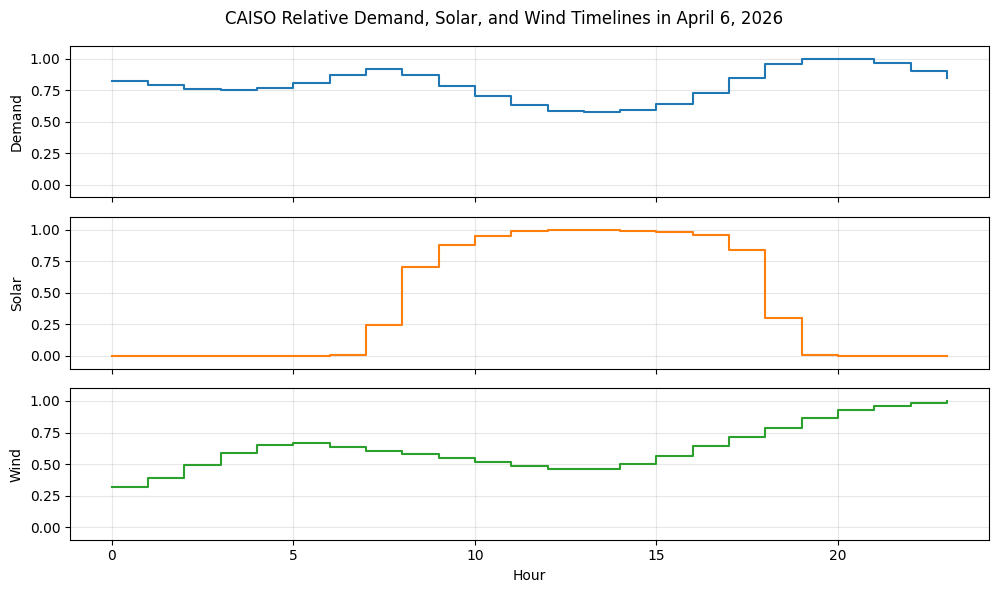

In [125]:
demand_timeline, solar_timeline, wind_timeline = load_caiso_timelines()
df_timeline = pd.DataFrame({
    "demand_timeline": demand_timeline,
    "solar_timeline": solar_timeline,
    "wind_timeline": wind_timeline
})

df_timeline

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

axes[0].step(df_timeline.index, df_timeline["demand_timeline"], where="post", color="tab:blue")
axes[0].set_ylabel("Demand")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.1, 1.1)

axes[1].step(df_timeline.index, df_timeline["solar_timeline"], where="post", color="tab:orange")
axes[1].set_ylabel("Solar")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.1, 1.1)

axes[2].step(df_timeline.index, df_timeline["wind_timeline"], where="post", color="tab:green")
axes[2].set_ylabel("Wind")
axes[2].set_xlabel("Hour")
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.1, 1.1)

fig.suptitle("CAISO Relative Demand, Solar, and Wind Timelines in April 6, 2026")
plt.tight_layout()
plt.show()

In [126]:
results = []

for hour in tqdm.tqdm(range(0, 24)):
    demand_ratio = demand_timeline[hour]
    solar_ratio = solar_timeline[hour]
    wind_ratio = wind_timeline[hour]
    
    
    total_dc_load = 150
    dc_load_A = total_dc_load / 3
    dc_load_B = total_dc_load / 3
    dc_load_C = total_dc_load / 3
    dc_loads = [dc_load_A, dc_load_B, dc_load_C]
    
    net, metrics = simulate_workload_shift(
        dc_loads=dc_loads, 
        wind_ratio=wind_ratio, 
        solar_ratio=solar_ratio, 
        demand_ratio=demand_ratio
    )
    if metrics is not None:
        metrics['DC_Load_A'] = dc_load_A
        metrics['DC_Load_B'] = dc_load_B
        metrics['DC_Load_C'] = dc_load_C
        results.append(metrics)
    else:
        print(f"OPF does not converge: A={dc_load_A}MW, B={dc_load_B}MW")
        
    # plot_net(net)
        
df_results = pd.DataFrame(results)
df_results

100%|██████████| 24/24 [00:12<00:00,  1.88it/s]


,LMP_A,LMP_B,LMP_C,Max_Line_Loading,Total_Load,Thermal_Output_MW,Actual_Wind_MW,Actual_Solar_MW,Total_Curtailment_MW,Curtailment_Percentage,Grid_Generation_Cost,Average_Carbon_Intensity,Carbon_Emissions_Ton,DC_Load_A,DC_Load_B,DC_Load_C
0,10.0,10.0,10.0,34.51,395.59,301.33,94.26,0.00,0.00,0.00,3013.34,0.7617,301.33,50.0,50.0,50.0
1,10.0,10.0,10.0,39.21,386.77,269.13,117.64,0.00,0.00,0.00,2691.33,0.6959,269.13,50.0,50.0,50.0
2,10.0,10.0,10.0,48.96,378.85,231.96,146.89,0.00,0.00,0.00,2319.57,0.6123,231.96,50.0,50.0,50.0
3,10.0,10.0,10.0,58.83,375.51,199.01,176.50,-0.00,0.00,0.00,1990.11,0.5300,199.01,50.0,50.0,50.0
4,10.0,10.0,10.0,66.91,379.07,183.94,195.13,0.00,0.00,0.00,1839.38,0.4852,183.94,50.0,50.0,50.0
5,10.0,10.0,10.0,67.55,391.48,192.28,199.20,0.00,0.00,0.00,1922.84,0.4912,192.28,50.0,50.0,50.0
6,10.0,10.0,10.0,63.63,411.28,219.07,190.88,1.32,0.00,0.00,2190.73,0.5327,219.07,50.0,50.0,50.0
7,10.0,10.0,10.0,74.42,424.39,169.36,180.42,74.61,0.00,0.00,1693.61,0.3991,169.36,50.0,50.0,50.0
8,10.0,0.0,10.0,100.00,411.53,74.36,168.59,168.59,47.09,12.26,743.55,0.1807,74.36,50.0,50.0,50.0
9,10.0,0.0,10.0,100.00,384.84,56.56,164.14,164.14,101.27,23.58,565.60,0.1470,56.56,50.0,50.0,50.0


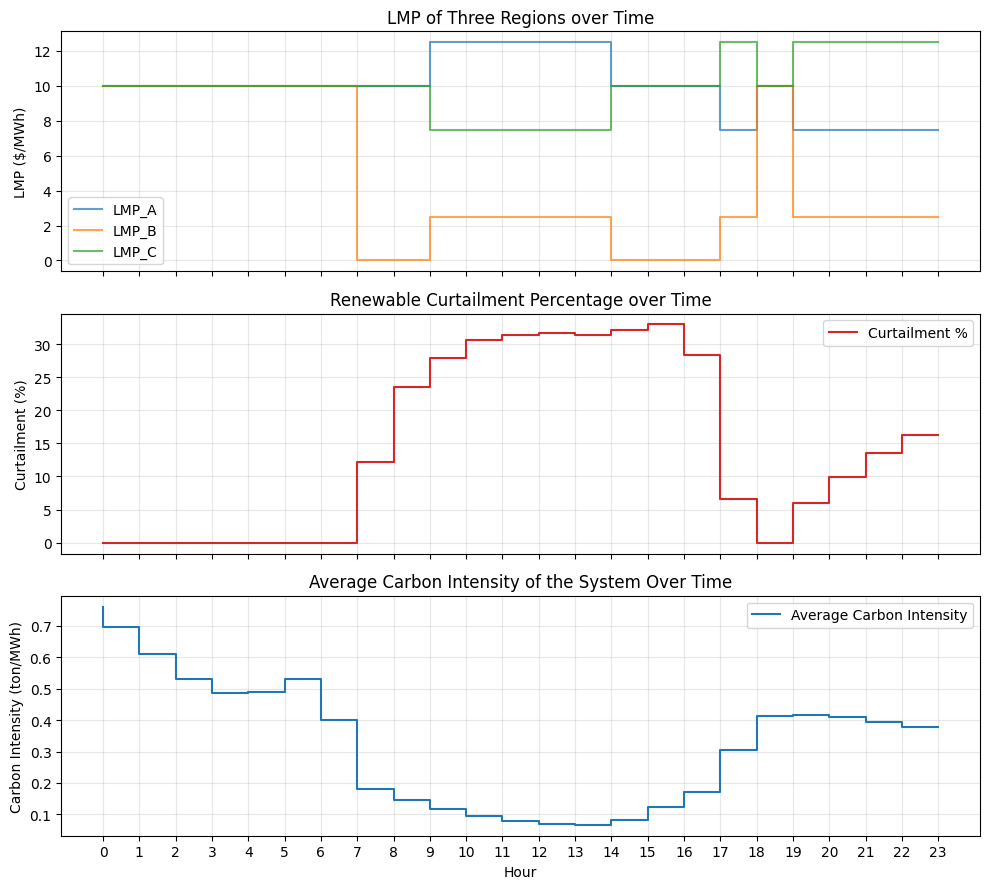

In [127]:
plot_results(df_results)

In [191]:
results = []
hour = 10
demand_ratio = demand_timeline[hour]
solar_ratio = solar_timeline[hour]
wind_ratio = wind_timeline[hour]


total_dc_load = 150
dc_load_A = total_dc_load / 3
dc_load_B = total_dc_load / 3
dc_load_C = total_dc_load / 3
dc_loads = [dc_load_A, dc_load_B, dc_load_C]

net, metrics = simulate_workload_shift(
    dc_loads=dc_loads, 
    wind_ratio=wind_ratio, 
    solar_ratio=solar_ratio, 
    demand_ratio=demand_ratio
)
if metrics is not None:
    metrics['DC_Load_A'] = dc_load_A
    metrics['DC_Load_B'] = dc_load_B
    metrics['DC_Load_C'] = dc_load_C
    results.append(metrics)
else:
    print(f"OPF does not converge: A={dc_load_A}MW, B={dc_load_B}MW")
    
plot_net(net)
        
df_results = pd.DataFrame(results)
df_results

,LMP_A,LMP_B,LMP_C,Max_Line_Loading,Total_Load,Thermal_Output_MW,Actual_Wind_MW,Actual_Solar_MW,Total_Curtailment_MW,Curtailment_Percentage,Grid_Generation_Cost,Average_Carbon_Intensity,Carbon_Emissions_Ton,DC_Load_A,DC_Load_B,DC_Load_C
0,12.5,2.5,7.5,100.0,360.01,42.51,155.0,162.5,122.74,27.88,425.07,0.1181,42.51,50.0,50.0,50.0


In [161]:
net.line

,name,std_type,from_bus,to_bus,length_km,r_ohm_per_km,x_ohm_per_km,c_nf_per_km,g_us_per_km,max_i_ka,df,parallel,type,in_service,max_loading_percent,geo
0,None,None,0,3,1.0,0.000000,0.1,0.000000,0.0,1.673479,1.0,1,ol,True,100.0,None
1,None,None,3,4,1.0,20.234250,0.1,352.117636,0.0,1.673479,1.0,1,ol,True,100.0,None
2,None,None,4,5,1.0,46.419750,0.1,797.836164,0.0,0.167348,1.0,1,ol,True,100.0,None
3,None,None,2,5,1.0,0.000000,0.1,0.000000,0.0,0.502044,1.0,1,ol,True,100.0,None
4,None,None,5,6,1.0,14.163975,0.1,465.775861,0.0,0.502044,1.0,1,ol,True,100.0,None
5,None,None,6,7,1.0,10.117125,0.1,332.060303,0.0,0.502044,1.0,1,ol,True,100.0,None
6,None,None,7,1,1.0,0.000000,0.1,0.000000,0.0,0.502044,1.0,1,ol,True,100.0,None
7,None,None,7,8,1.0,38.088000,0.1,681.949347,0.0,0.167348,1.0,1,ol,True,100.0,None
8,None,None,8,3,1.0,11.902500,0.1,392.232304,0.0,1.673479,1.0,1,ol,True,100.0,None


In [160]:
net.load

,name,bus,p_mw,q_mvar,const_z_p_percent,const_z_q_percent,const_i_p_percent,const_i_q_percent,sn_mva,scaling,in_service,type,controllable
0,None,4,124.677507,0.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
1,None,6,162.177507,0.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False
2,None,8,124.677507,0.0,0.0,0.0,0.0,0.0,NaN,1.0,True,None,False


In [129]:
net.bus

,name,vn_kv,type,zone,in_service,max_vm_pu,min_vm_pu,geo
0,1,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-2.9134066523, -0.6438752673]..."
1,2,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [0.9369913411, -0.1173671421],..."
2,3,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-1.4518205307, 2.940568212], ..."
3,4,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-2.0549411928, 0.0097926866],..."
4,5,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-2.1789060589, 1.1489200593],..."
5,6,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-1.2943983522, 1.8718889109],..."
6,7,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-0.2434998231, 1.4166043723],..."
7,8,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-0.0639025421, 0.2858212795],..."
8,9,345.0,b,1.0,True,1.1,0.9,"{""coordinates"": [-0.9830230267, -0.3940948828]..."


In [144]:
results = []

hour = 8

for dc_B_load_ratio in tqdm.tqdm(range(0, 101, 5)):
    dc_B_load_ratio *= 0.01
    demand_ratio = demand_timeline[hour]
    solar_ratio = solar_timeline[hour]
    wind_ratio = wind_timeline[hour]
    
    total_dc_load = 150
    
    dc_load_B = total_dc_load * dc_B_load_ratio
    dc_load_A = (total_dc_load - dc_load_B) / 2
    dc_load_C = (total_dc_load - dc_load_B) / 2
    
    dc_loads = [dc_load_A, dc_load_B, dc_load_C]
    
    net, metrics = simulate_workload_shift(
        dc_loads=dc_loads, 
        wind_ratio=wind_ratio, 
        solar_ratio=solar_ratio, 
        demand_ratio=demand_ratio
    )
    if metrics is not None:
        metrics['DC_Load_A'] = dc_load_A
        metrics['DC_Load_B'] = dc_load_B
        metrics['DC_Load_C'] = dc_load_C
        results.append(metrics)
    else:
        print(f"OPF does not converge: A={dc_load_A}MW, B={dc_load_B}MW")
        
    # plot_net(net)
        
df_results = pd.DataFrame(results)
df_results

100%|██████████| 21/21 [00:11<00:00,  1.83it/s]


,LMP_A,LMP_B,LMP_C,Max_Line_Loading,Total_Load,Thermal_Output_MW,Actual_Wind_MW,Actual_Solar_MW,Total_Curtailment_MW,Curtailment_Percentage,Grid_Generation_Cost,Average_Carbon_Intensity,Carbon_Emissions_Ton,DC_Load_A,DC_Load_B,DC_Load_C
0,10.0,0.0,10.0,100.00,411.53,124.36,143.59,143.59,97.09,25.27,1243.55,0.3022,124.36,75.00,0.0,75.00
1,10.0,0.0,10.0,100.00,411.53,116.86,147.34,147.34,89.59,23.32,1168.55,0.2840,116.86,71.25,7.5,71.25
2,10.0,0.0,10.0,100.00,411.53,109.36,151.09,151.09,82.09,21.36,1093.55,0.2657,109.36,67.50,15.0,67.50
3,10.0,0.0,10.0,100.00,411.53,101.86,154.84,154.84,74.59,19.41,1018.55,0.2475,101.86,63.75,22.5,63.75
4,10.0,0.0,10.0,100.00,411.53,94.36,158.59,158.59,67.09,17.46,943.55,0.2293,94.36,60.00,30.0,60.00
5,10.0,0.0,10.0,100.00,411.53,86.86,162.34,162.34,59.59,15.51,868.55,0.2111,86.86,56.25,37.5,56.25
6,10.0,0.0,10.0,100.00,411.53,79.36,166.09,166.09,52.09,13.56,793.55,0.1928,79.36,52.50,45.0,52.50
7,10.0,0.0,10.0,100.00,411.53,71.86,169.84,169.84,44.59,11.60,718.55,0.1746,71.86,48.75,52.5,48.75
8,12.5,2.5,7.5,100.00,411.53,64.70,172.90,173.93,37.44,9.74,647.00,0.1572,64.70,45.00,60.0,45.00
9,12.5,2.5,7.5,100.00,411.53,59.07,172.90,179.56,31.81,8.28,590.75,0.1435,59.07,41.25,67.5,41.25


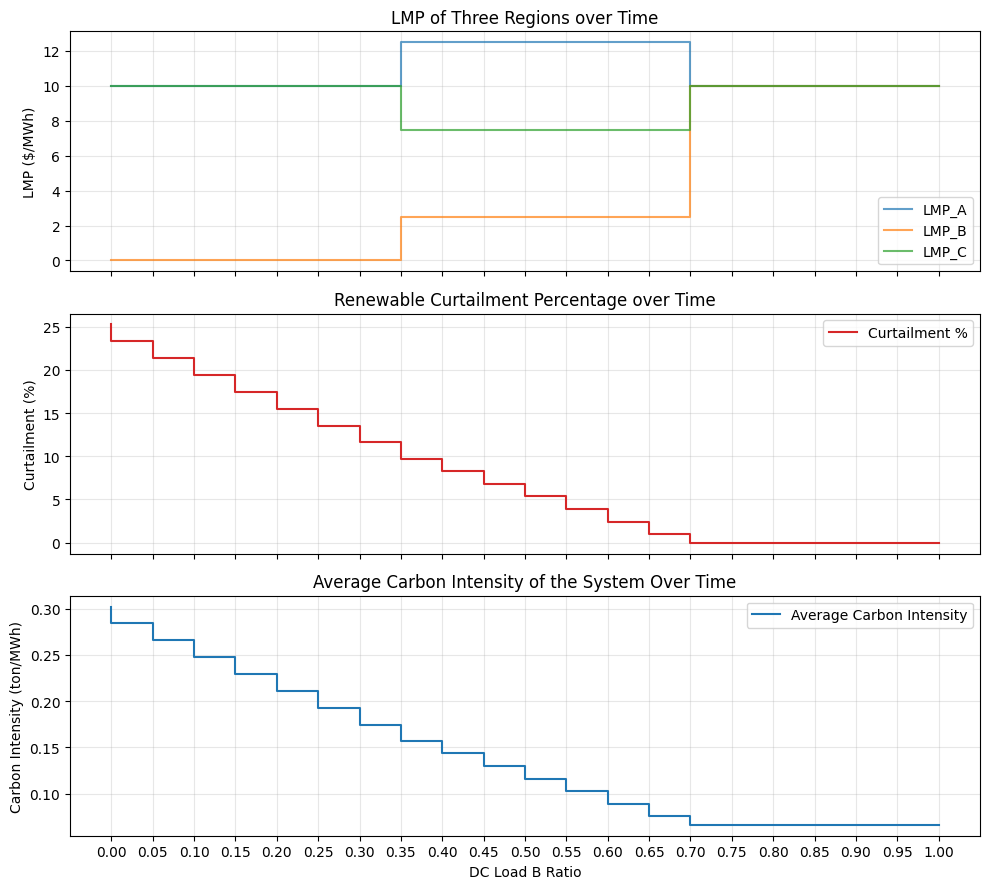

In [145]:
plot_results(df_results, x_label="DC Load B Ratio", x_ticks=np.arange(0, 101, 5) * 0.01)

In [159]:
results = []

hour = 8

dc_B_load_ratio = 0.5
demand_ratio = demand_timeline[hour]
solar_ratio = solar_timeline[hour]
wind_ratio = wind_timeline[hour]

total_dc_load = 150

dc_load_B = total_dc_load * dc_B_load_ratio
dc_load_A = (total_dc_load - dc_load_B) / 2
dc_load_C = (total_dc_load - dc_load_B) / 2

dc_loads = [dc_load_A, dc_load_B, dc_load_C]

net, metrics = simulate_workload_shift(
    dc_loads=dc_loads, 
    wind_ratio=wind_ratio, 
    solar_ratio=solar_ratio, 
    demand_ratio=demand_ratio
)
if metrics is not None:
    metrics['DC_Load_A'] = dc_load_A
    metrics['DC_Load_B'] = dc_load_B
    metrics['DC_Load_C'] = dc_load_C
    results.append(metrics)
else:
    print(f"OPF does not converge: A={dc_load_A}MW, B={dc_load_B}MW")
    
plot_net(net)

df_results = pd.DataFrame(results)
df_results

,LMP_A,LMP_B,LMP_C,Max_Line_Loading,Total_Load,Thermal_Output_MW,Actual_Wind_MW,Actual_Solar_MW,Total_Curtailment_MW,Curtailment_Percentage,Grid_Generation_Cost,Average_Carbon_Intensity,Carbon_Emissions_Ton,DC_Load_A,DC_Load_B,DC_Load_C
0,12.5,2.5,7.5,100.0,411.53,53.45,172.9,185.18,26.19,6.82,534.5,0.1299,53.45,37.5,75.0,37.5


In [141]:
results = []

hour = 8

for dc_B_load_ratio in tqdm.tqdm(range(0, 101, 5)):
    dc_B_load_ratio *= 0.01
    demand_ratio = demand_timeline[hour]
    solar_ratio = solar_timeline[hour]
    wind_ratio = wind_timeline[hour]
    
    total_dc_load = 150
    
    dc_load_B = total_dc_load * dc_B_load_ratio
    dc_load_A = 50
    dc_load_C = 50
    
    dc_loads = [dc_load_A, dc_load_B, dc_load_C]
    
    net, metrics = simulate_workload_shift(
        dc_loads=dc_loads, 
        wind_ratio=wind_ratio, 
        solar_ratio=solar_ratio, 
        demand_ratio=demand_ratio
    )
    if metrics is not None:
        metrics['DC_Load_A'] = dc_load_A
        metrics['DC_Load_B'] = dc_load_B
        metrics['DC_Load_C'] = dc_load_C
        results.append(metrics)
    else:
        print(f"OPF does not converge: A={dc_load_A}MW, B={dc_load_B}MW")
        
    # plot_net(net)
        
df_results = pd.DataFrame(results)
df_results

100%|██████████| 21/21 [00:10<00:00,  1.92it/s]


,LMP_A,LMP_B,LMP_C,Max_Line_Loading,Total_Load,Thermal_Output_MW,Actual_Wind_MW,Actual_Solar_MW,Total_Curtailment_MW,Curtailment_Percentage,Grid_Generation_Cost,Average_Carbon_Intensity,Carbon_Emissions_Ton,DC_Load_A,DC_Load_B,DC_Load_C
0,10.0,0.0,10.0,100.00,361.53,74.36,143.59,143.59,97.09,25.27,743.55,0.2057,74.36,50,0.0,50
1,10.0,0.0,10.0,100.00,369.03,74.36,147.34,147.34,89.59,23.32,743.55,0.2015,74.36,50,7.5,50
2,10.0,0.0,10.0,100.00,376.53,74.36,151.09,151.09,82.09,21.36,743.55,0.1975,74.36,50,15.0,50
3,10.0,0.0,10.0,100.00,384.03,74.36,154.84,154.84,74.59,19.41,743.55,0.1936,74.36,50,22.5,50
4,10.0,0.0,10.0,100.00,391.53,74.36,158.59,158.59,67.09,17.46,743.55,0.1899,74.36,50,30.0,50
5,10.0,0.0,10.0,100.00,399.03,74.36,162.34,162.34,59.59,15.51,743.55,0.1863,74.36,50,37.5,50
6,10.0,0.0,10.0,100.00,406.53,74.36,166.09,166.09,52.09,13.56,743.55,0.1829,74.36,50,45.0,50
7,10.0,0.0,10.0,100.00,414.03,74.36,169.84,169.84,44.59,11.60,743.55,0.1796,74.36,50,52.5,50
8,12.5,2.5,7.5,100.00,421.53,74.70,172.90,173.93,37.44,9.74,747.00,0.1772,74.70,50,60.0,50
9,12.5,2.5,7.5,100.00,429.03,76.57,172.90,179.56,31.81,8.28,765.75,0.1785,76.57,50,67.5,50


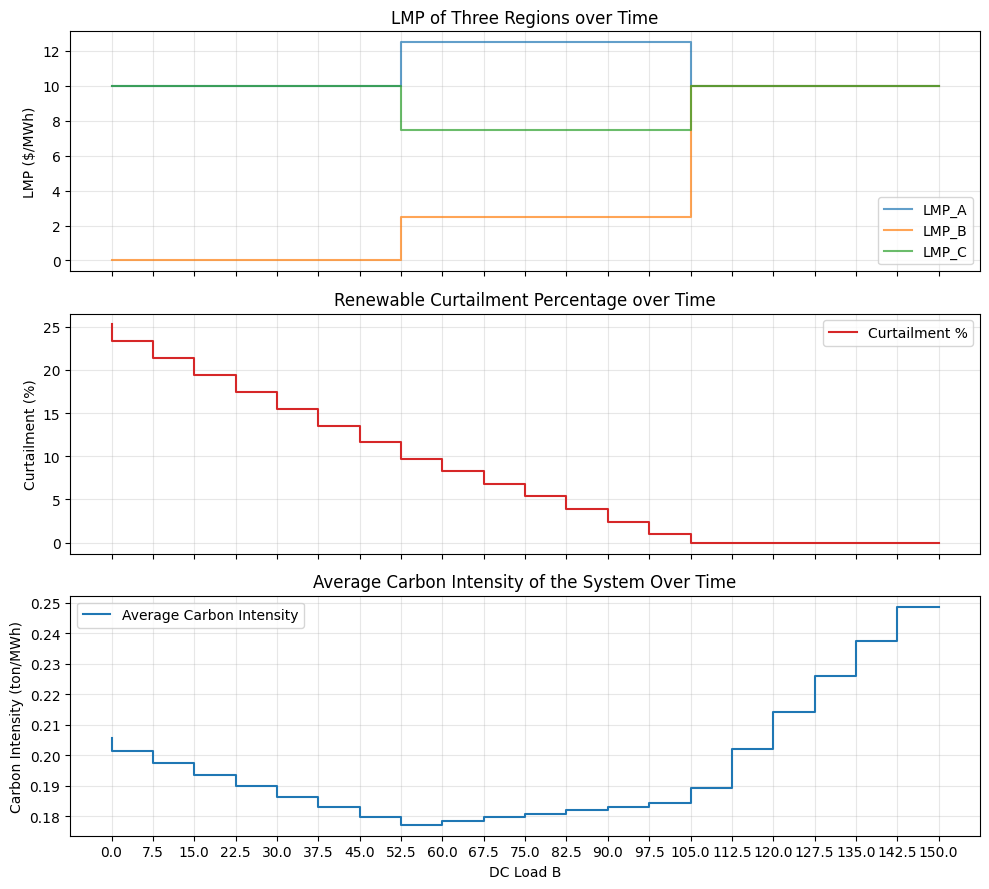

In [143]:
plot_results(df_results, x_label="DC Load B", x_ticks=np.arange(0, 101, 5) * 0.01 * total_dc_load)

In [146]:
results = []

hour = 8

dc_B_load_ratio = 0.5
demand_ratio = demand_timeline[hour]
solar_ratio = solar_timeline[hour]
wind_ratio = wind_timeline[hour]

total_dc_load = 150

dc_load_B = total_dc_load * dc_B_load_ratio
dc_load_A = (total_dc_load - dc_load_B) / 2
dc_load_C = (total_dc_load - dc_load_B) / 2

dc_loads = [dc_load_A, dc_load_B, dc_load_C]

net, metrics = simulate_workload_shift(
    dc_loads=dc_loads, 
    wind_ratio=wind_ratio, 
    solar_ratio=solar_ratio, 
    demand_ratio=demand_ratio
)
if metrics is not None:
    metrics['DC_Load_A'] = dc_load_A
    metrics['DC_Load_B'] = dc_load_B
    metrics['DC_Load_C'] = dc_load_C
    results.append(metrics)
else:
    print(f"OPF does not converge: A={dc_load_A}MW, B={dc_load_B}MW")
    
plot_net(net)

df_results = pd.DataFrame(results)
df_results

,LMP_A,LMP_B,LMP_C,Max_Line_Loading,Total_Load,Thermal_Output_MW,Actual_Wind_MW,Actual_Solar_MW,Total_Curtailment_MW,Curtailment_Percentage,Grid_Generation_Cost,Average_Carbon_Intensity,Carbon_Emissions_Ton,DC_Load_A,DC_Load_B,DC_Load_C
0,12.5,2.5,7.5,100.0,411.53,53.45,172.9,185.18,26.19,6.82,534.5,0.1299,53.45,37.5,75.0,37.5


In [4]:
def plot_net(net):
    import json

    def _parse_point(geo_value):
        if pd.isna(geo_value):
            return None
        geo_obj = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
        x, y = geo_obj["coordinates"]
        return pd.Series({"x": float(x), "y": float(y)})

    def _get_bus_coords(net):
        if hasattr(net, "bus_geodata") and not net.bus_geodata.empty and {"x", "y"}.issubset(net.bus_geodata.columns):
            return net.bus_geodata[["x", "y"]].astype(float)

        if "geo" not in net.bus.columns or net.bus.geo.dropna().empty:
            plot.create_generic_coordinates(net, overwrite=True)

        bus_coords = net.bus.geo.dropna().apply(_parse_point)
        if bus_coords.empty:
            raise ValueError("No bus coordinates are available for plotting.")
        return bus_coords

    pp.rundcopp(net)
    bus_coords = _get_bus_coords(net)

    vn_kv = net.bus.loc[net.line.from_bus.values, 'vn_kv'].values
    max_i_ka = net.line.max_i_ka.values
    max_load_mw = np.sqrt(3) * vn_kv * max_i_ka

    line_hover = pd.Series(
        ("Line " + net.line.index.astype(str) + \
        "<br>From: Bus " + net.line.from_bus.astype(str) + \
        "  To: Bus " + net.line.to_bus.astype(str) + \
        "<br>P_flow: " + abs(net.res_line.p_from_mw).round(2).astype(str) + " MW" + \
        "<br>Max Cap: " + np.round(max_load_mw, 2).astype(str) + " MW" + \
        "<br>Loading: " + net.res_line.loading_percent.round(2).astype(str) + " %").values,
        index=net.line.index
    )

    gen_cost = net.gen.index.map(
        net.poly_cost.loc[net.poly_cost.et == 'gen'].set_index('element')['cp1_eur_per_mw']
    ).fillna(0).round(2).astype(str)
    gen_hover = pd.Series(
        ("Gen " + net.gen.index.astype(str) +
        "<br>P_out: " + net.res_gen.p_mw.round(2).astype(str) + " MW" +
        "<br>Min P: " + net.gen.min_p_mw.round(2).astype(str) + " MW" +
        "<br>Max P: " + net.gen.max_p_mw.round(2).astype(str) + " MW" +
        "<br>Cost: " + gen_cost.values + " $/MW").values,
        index=net.gen.bus.values
    )

    lmp_col = next((col for col in ["lam_p", "marginal_price"] if col in net.res_bus.columns), None)
    lmp_values = (
        net.load.bus.map(net.res_bus[lmp_col]).round(2).astype(str) + " $/MWh"
        if lmp_col is not None else pd.Series(["N/A"] * len(net.load), index=net.load.index)
    )
    load_hover = pd.Series(
        ("Load " + net.load.index.astype(str) +
        "<br>Bus: " + net.load.bus.astype(str) +
        "<br>P_in: " + net.res_load.p_mw.round(2).astype(str) + " MW" +
        "<br>LMP: " + lmp_values.values).values,
        index=net.load.bus.values
    )

    line_trace = pplotly.create_line_trace(
        net, use_line_geo=False, cmap="jet", cmap_vals=net.res_line.loading_percent,
        cmin=0, cmax=100, infofunc=line_hover, width=3.0
    )
    for trace in line_trace:
        if 'marker' in trace and 'showscale' in trace['marker']:
            trace['marker']['showscale'] = False
            trace['showlegend'] = False

    pure_buses = list(set(net.bus.index) - set(net.gen.bus) - set(net.load.bus) - set(net.ext_grid.bus))
    bus_trace = pplotly.create_bus_trace(
        net, buses=pure_buses, size=10, color="lightgray", trace_name="Buses",
        infofunc=pd.Series(("Bus " + net.bus.index.astype(str)).values, index=net.bus.index)
    )

    gen_trace = pplotly.create_bus_trace(
        net, buses=net.gen.bus.values, size=16, color="orange", trace_name="Generators", infofunc=gen_hover
    )

    load_trace = pplotly.create_bus_trace(
        net, buses=net.load.bus.values, size=16, color="blue", trace_name="Loads", infofunc=load_hover
    )

    arrow_mid_x = []
    arrow_mid_y = []
    arrow_angles = []
    arrow_colors = []

    for idx, row in net.line.iterrows():
        if not row.in_service:
            continue

        from_bus = row.from_bus
        to_bus = row.to_bus
        if from_bus not in bus_coords.index or to_bus not in bus_coords.index:
            continue

        x0, y0 = bus_coords.loc[from_bus, ['x', 'y']]
        x1, y1 = bus_coords.loc[to_bus, ['x', 'y']]

        p_from = net.res_line.loc[idx, 'p_from_mw']
        loading = net.res_line.loc[idx, 'loading_percent']

        if pd.isna(p_from) or pd.isna(loading) or loading < 0.01:
            continue

        if p_from > 0:
            tail_x, tail_y = x0, y0
            head_x, head_y = x1, y1
        elif p_from < 0:
            tail_x, tail_y = x1, y1
            head_x, head_y = x0, y0
        else:
            continue

        mid_x = (x0 + x1) / 2
        mid_y = (y0 + y1) / 2
        arrow_mid_x.append(mid_x)
        arrow_mid_y.append(mid_y)

        angle_rad = np.arctan2(head_y - tail_y, head_x - tail_x)
        plotly_angle = 90 - np.degrees(angle_rad)
        arrow_angles.append(plotly_angle)

        norm_loading = np.clip(loading / 100.0, 0.0, 1.0)
        plotly_color = pcolors.sample_colorscale('jet', [norm_loading])[0]
        arrow_colors.append(plotly_color)

    arrow_trace = go.Scatter(
        x=arrow_mid_x,
        y=arrow_mid_y,
        mode='markers',
        marker=dict(
            symbol='triangle-up',
            size=14,
            color=arrow_colors,
            angle=arrow_angles,
            line=dict(color='black', width=0.5)
        ),
        showlegend=False,
        hoverinfo='skip',
    )

    traces = line_trace + bus_trace + gen_trace + load_trace + [arrow_trace]
    fig = go.Figure(data=traces)

    x_min, x_max = bus_coords['x'].min(), bus_coords['x'].max()
    y_min, y_max = bus_coords['y'].min(), bus_coords['y'].max()
    margin_x = (x_max - x_min) * 0.1 if x_max != x_min else 1
    margin_y = (y_max - y_min) * 0.1 if y_max != y_min else 1

    fig.update_layout(
        xaxis=dict(range=[x_min - margin_x, x_max + margin_x], title="X Coordinate"),
        yaxis=dict(scaleanchor="x", scaleratio=1, range=[y_min - margin_y, y_max + margin_y], title="Y Coordinate"),
        width=700, height=700,
        showlegend=True,
        template="plotly_white",
        hovermode="closest"
    )

    fig.show()


In [6]:
import pandapower as pp
import math

net = pp.create_empty_network()

bus_gen1 = pp.create_bus(net, vn_kv=110, name="Bus 1")
bus_top = pp.create_bus(net, vn_kv=110, name="Bus 2")
bus_gen2 = pp.create_bus(net, vn_kv=110, name="Bus 3")
bus_bottom = pp.create_bus(net, vn_kv=110, name="Bus 4")
bus_load1 = pp.create_bus(net, vn_kv=110, name="Bus 5")
bus_load2 = pp.create_bus(net, vn_kv=110, name="Bus 6")

gen1 = pp.create_gen(net, bus=bus_gen1, p_mw=100, min_p_mw=0, max_p_mw=500, min_q_mvar=-500, max_q_mvar=500, name="Gen 1", slack=True)
pp.create_poly_cost(net, element=gen1, et="gen", cp1_eur_per_mw=10, cp0_eur=0)
gen2 = pp.create_gen(net, bus=bus_gen2, p_mw=100, min_p_mw=0, max_p_mw=500, min_q_mvar=-500, max_q_mvar=500, name="Gen 2",)
pp.create_poly_cost(net, element=gen2, et="gen", cp1_eur_per_mw=0, cp0_eur=0)

load1 = pp.create_load(net, bus=bus_load1, p_mw=100, controllable=False, name="Load 1")
load2 = pp.create_load(net, bus=bus_load2, p_mw=120, controllable=False, name="Load 2")

line1 = pp.create_line(net, from_bus=bus_gen1, to_bus=bus_top, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=100 + 1e-6)
line2 = pp.create_line(net, from_bus=bus_top, to_bus=bus_load1, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=100 + 1e-6)
line3 = pp.create_line(net, from_bus=bus_top, to_bus=bus_load2, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=100 + 1e-6)
line4 = pp.create_line(net, from_bus=bus_bottom, to_bus=bus_load1, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=100 + 1e-6)
line5 = pp.create_line(net, from_bus=bus_bottom, to_bus=bus_load2, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=100 + 1e-6)
line6 = pp.create_line(net, from_bus=bus_gen2, to_bus=bus_bottom, length_km=10, std_type="149-AL1/24-ST1A 110.0", max_loading_percent=100 + 1e-6)

net.line.loc[line1, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)
net.line.loc[line2, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)
net.line.loc[line3, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)
net.line.loc[line4, 'max_i_ka'] = 50 / (math.sqrt(3) * 110)
net.line.loc[line5, 'max_i_ka'] = 50 / (math.sqrt(3) * 110)
net.line.loc[line6, 'max_i_ka'] = 500 / (math.sqrt(3) * 110)


pp.rundcopp(net)


plot_net(net)